# Chapter: Feature Engineering Pipelines
## Feature Engineering & MLOps

**The problem this chapter solves:** imagine preprocessing your training data manually — scale
this column, encode that one, impute the missing values — and then, weeks later, accidentally
preprocessing PRODUCTION data slightly differently. The model was never wrong; the DATA it saw
in production just didn't match what it learned on. This chapter is about making that mistake
structurally impossible.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain why manually repeating preprocessing steps for training and inference is risky
- Build a `ColumnTransformer` that treats numeric and categorical columns differently, in one object
- Chain preprocessing and a model together into a single `sklearn.Pipeline`
- Call `.fit()` and `.predict()` on a pipeline exactly the way you would on a plain model
- Explain why pipelines matter for reproducibility, leakage prevention, and deployment

## Real-World Problem

You work at a telecom company (same business as our Data Leakage chapter). You've built a churn
model that works great in your notebook. Six weeks later, a colleague on the engineering team
needs to wire it up to score NEW customers in production, in real time.

- **Raw data available:** `age`, `income`, `monthly_spend`, `contract_type`, `city`,
  `support_calls` — a mix of numeric and categorical columns, with some missing values.
- **Target:** `churn`.
- **The catch:** your notebook scaled the numeric columns and one-hot encoded the categorical
  ones by hand, using specific pandas code, in a specific order, with specific fill values for
  missing data. Your colleague, working from a different script, has to somehow reproduce every
  one of those steps EXACTLY — or the model will be fed data it doesn't recognize.
- **Why the business cares:** a subtle mismatch here doesn't crash anything — it just quietly
  produces wrong predictions, which is far more dangerous than an error message, because nobody
  notices until customers start churning that the model swore weren't at risk.

## Why Do We Need This Concept?

Every preprocessing step you apply to training data — imputing missing values, scaling numbers,
encoding categories — has to be applied **identically** to any new data the model will ever see,
whether that's your test set today or a live customer application six months from now.

```
TRAINING:    Raw data  ->  preprocessing  ->  features  ->  model  ->  (learns patterns)
INFERENCE:   Raw data  ->  SAME preprocessing  ->  features  ->  model  ->  prediction
                           ^^^^^^^^^^^^^^^^^^^
                           if this isn't IDENTICAL, the model is confused
                           by data shaped differently than what it learned on
```

If training and inference preprocessing ever drift apart — even slightly — you get
**training-serving skew**: the model was never technically wrong, but the data it's being
asked to score doesn't match what it learned from, so its predictions quietly stop making
sense. This is one of the most common real causes of "the model worked in testing but is bad
in production."

## Concept Intuition

```
RAW DATA
    |
    v
ColumnTransformer
    +-- numerical columns   -> impute (fill missing) -> scale
    +-- categorical columns -> impute (fill missing) -> one-hot encode
    |
    v
Combined feature matrix
    |
    v
   Model
    |
    v
 Prediction
```

A `Pipeline` wraps this ENTIRE flow — from raw columns to a final prediction — into ONE object.
Instead of remembering five separate steps in the right order, you call `.fit()` once and
`.predict()` once, and the object itself guarantees every step happens identically, every time,
for every row it ever sees.

## Tiny Manual Example

Let's see the WRONG way first, on 4 tiny rows, so the risk is completely concrete.

In [1]:
import pandas as pd
import numpy as np

toy = pd.DataFrame({
    "age": [25, 40, np.nan, 55],
    "monthly_spend": [50, 80, 65, np.nan],
    "contract_type": ["Month-to-month", "Two year", "One year", "Month-to-month"],
})
toy

,age,monthly_spend,contract_type
0,25.0,50.0,Month-to-month
1,40.0,80.0,Two year
2,NaN,65.0,One year
3,55.0,NaN,Month-to-month


**The manual (risky) way:**
```
Step 1: fill missing age with the mean age        -> mean = (25+40+55)/3 = 40.0
Step 2: fill missing monthly_spend with its mean   -> mean = (50+80+65)/3 = 65.0
Step 3: scale age and monthly_spend by hand
Step 4: one-hot encode contract_type by hand
```
Now imagine a NEW customer arrives next month: `age=30, monthly_spend=NaN,
contract_type="Two year"`. To score them, someone has to remember: *"fill missing
monthly_spend with 65.0 — no wait, was that the mean from THIS batch, or the original training
batch? Did we scale using this batch's mean and std, or the original ones?"* Every one of these
questions is a chance to get it subtly wrong. A `Pipeline` remembers the answer for you,
automatically, because it stores the exact fitted values (means, categories seen) from
training and reuses them — never recalculating from whatever data happens to be in front of it.

## Python Implementation

### Step 1 — Load the real dataset

In [2]:
df = pd.read_csv("../data/raw/customer_pipeline_data.csv")
print(df.shape)
print(df.isna().sum())
df.head()

(400, 8)
customer_id       0
age              20
income           40
monthly_spend    16
contract_type     0
city             12
support_calls     0
churn             0
dtype: int64


,customer_id,age,income,monthly_spend,contract_type,city,support_calls,churn
0,5219,34.0,NaN,73.82,Month-to-month,Delhi,2,0
1,5192,57.0,57000.0,87.35,Month-to-month,Chennai,2,0
2,5118,27.0,65800.0,97.59,Month-to-month,Pune,3,0
3,5051,35.0,33400.0,69.89,Month-to-month,Chennai,3,1
4,5349,34.0,75600.0,55.66,Two year,Chennai,1,0


### Step 2 — The WRONG approach: manual preprocessing, done by hand

This is the kind of code that looks completely reasonable — until someone has to reproduce it
exactly, somewhere else, later.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- Manually scale numerical features (easy to do inconsistently between train/test) ---
X_train_wrong = X_train.copy()
X_test_wrong = X_test.copy()

numeric_cols = ["age", "income", "monthly_spend", "support_calls"]
for col in numeric_cols:
    fill_value = X_train_wrong[col].mean()          # decision #1: what do we fill with?
    X_train_wrong[col] = X_train_wrong[col].fillna(fill_value)
    X_test_wrong[col] = X_test_wrong[col].fillna(fill_value)   # easy to forget to reuse this!

    mean, std = X_train_wrong[col].mean(), X_train_wrong[col].std()   # decision #2: scale how?
    X_train_wrong[col] = (X_train_wrong[col] - mean) / std
    X_test_wrong[col] = (X_test_wrong[col] - mean) / std

# --- Manually encode categorical features ---
X_train_wrong["city"] = X_train_wrong["city"].fillna("Unknown")
X_test_wrong["city"] = X_test_wrong["city"].fillna("Unknown")

X_train_wrong = pd.get_dummies(X_train_wrong, columns=["contract_type", "city"])
X_test_wrong = pd.get_dummies(X_test_wrong, columns=["contract_type", "city"])

# THE MISTAKE: get_dummies can produce DIFFERENT columns for train vs test if a category
# is missing from one split by chance -- exactly the kind of subtle bug pipelines prevent
print("Train columns:", X_train_wrong.shape[1])
print("Test columns: ", X_test_wrong.shape[1])
print("Columns match:", list(X_train_wrong.columns) == list(X_test_wrong.columns))

Train columns: 13
Test columns:  13
Columns match: True


**What to notice:** even in this careful-looking manual code, we already had to make several
silent decisions (what to fill missing values with, how to scale, how to encode) that all have
to be repeated PERFECTLY elsewhere. And `pd.get_dummies()` can silently produce mismatched
columns between train and test if a category happens to be missing from one split — the kind
of bug that doesn't throw an error, it just quietly breaks your model.

### Step 3 — The CORRECT approach: `ColumnTransformer` + `Pipeline`

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["age", "income", "monthly_spend", "support_calls"]
categorical_features = ["contract_type", "city"]

# Numeric columns: fill missing with the median, then scale
numeric_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Categorical columns: fill missing with the most common value, then one-hot encode
# handle_unknown="ignore" means a brand-new category at inference time won't crash anything
categorical_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer routes each column list to its own pipeline, then combines the results
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# The FULL pipeline: preprocessing + model, as one single object
full_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### Step 4 — Fit and predict, exactly like a plain model

In [5]:
full_pipeline.fit(X_train, y_train)   # fits imputers, scaler, encoder, AND the model -- all at once

pred = full_pipeline.predict(X_test)
proba = full_pipeline.predict_proba(X_test)[:, 1]

print(f"Test accuracy: {accuracy_score(y_test, pred):.1%}")

from sklearn.metrics import roc_auc_score
print(f"Test ROC-AUC:  {roc_auc_score(y_test, proba):.3f}")

Test accuracy: 77.0%
Test ROC-AUC:  0.763


In [6]:
# Score a single BRAND NEW customer -- notice we never manually touch any preprocessing step
new_customer = pd.DataFrame([{
    "age": 29, "income": 42000, "monthly_spend": np.nan,   # missing value -- handled automatically
    "contract_type": "Month-to-month", "city": "Mumbai", "support_calls": 3,
}])

churn_probability = full_pipeline.predict_proba(new_customer)[0, 1]
print(f"Predicted churn probability for this new customer: {churn_probability:.1%}")
print("Notice: the missing monthly_spend was imputed automatically, using the exact")
print("median learned from TRAINING data -- no manual step, no chance to get it wrong.")

Predicted churn probability for this new customer: 41.7%
Notice: the missing monthly_spend was imputed automatically, using the exact
median learned from TRAINING data -- no manual step, no chance to get it wrong.


## Visualization

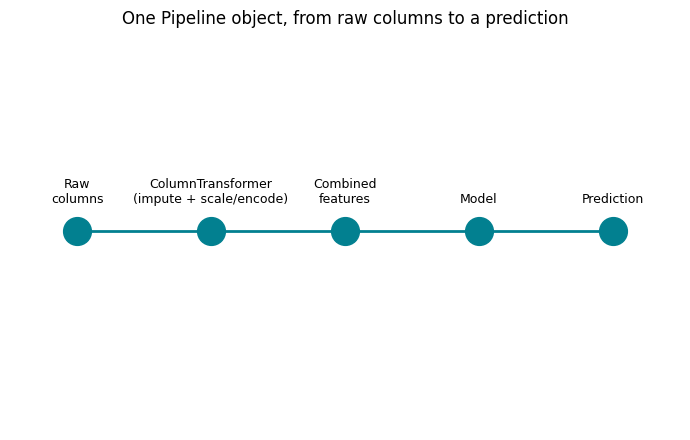

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
steps = ["Raw\ncolumns", "ColumnTransformer\n(impute + scale/encode)", "Combined\nfeatures", "Model", "Prediction"]
x_pos = range(len(steps))
ax.plot(x_pos, [1]*len(steps), marker="o", markersize=20, color="#028090", linewidth=2, zorder=2)
for i, step in enumerate(steps):
    ax.annotate(step, (i, 1), textcoords="offset points", xytext=(0, 20), ha="center", fontsize=9)
ax.set_xlim(-0.5, len(steps) - 0.5)
ax.set_ylim(0.5, 1.5)
ax.axis("off")
ax.set_title("One Pipeline object, from raw columns to a prediction")
plt.tight_layout()
plt.show()

**What should you notice?** Every box in this diagram lives INSIDE the single
`full_pipeline` object. There is no step where a human has to manually hand data from one stage
to the next — which is exactly what eliminates the risk of training and inference drifting
apart.

## Industry Case Study

**Banking — loan approval scoring.** A bank's data science team builds a loan default model in
a notebook, using pandas to manually scale income and one-hot encode employment type. The model
performs well. Six months later, the engineering team wraps it into a real-time API for the
loan origination system — and re-implements the preprocessing in a different language (Java),
based on a written description of "what the notebook did." A subtle rounding difference in how
income gets scaled means the production model sees slightly different numbers than the model
was trained on. Approval rates drift for months before anyone traces it back to this mismatch.

```
RAW DATA                FEATURE ENGINEERING           MODEL           BUSINESS DECISION
---------                --------------------          -----           ------------------
loan application   -->   scale income, encode     -->  predicts   -->  approve / decline
(income, employment       employment_type                default          the loan
 type, credit_score)      (re-implemented in a
                           DIFFERENT language,
                           slightly differently)
```

Had the original team shipped a single serialized `Pipeline` object (or the equivalent in
whatever serving stack the bank uses) instead of a written description of the steps, this entire
multi-month drift would have been structurally impossible — the exact same fitted object would
have been doing the preprocessing in both places.

## What Can Go Wrong?

**Mistake 1 — Fitting preprocessing on the full dataset before splitting**

- **Problem:** the scaler/imputer/encoder sees test rows during `fit()`, contaminating your
  validation score (this is preprocessing leakage — see the Data Leakage chapter).
- **Why it happens:** it's one line of code shorter to preprocess once, then split.
- **Example:** `StandardScaler().fit(X)` before `train_test_split(X, y)`.
- **How to detect it:** check whether any `.fit()` or `.fit_transform()` call happens before
  the split in your code.
- **How to fix it:** always split first; only ever call `.fit()` on `X_train`.

**Mistake 2 — Manually re-implementing preprocessing for inference**

- **Problem:** training and inference preprocessing silently drift apart over time.
- **Why it happens:** the two are written in different scripts, by different people, or at
  different times, with no single source of truth.
- **Example:** the banking case study above.
- **How to detect it:** ask — is there ONE object (a fitted `Pipeline`) that both training and
  inference call, or are there two separate implementations?
- **How to fix it:** serialize the fitted `Pipeline` (e.g., with `joblib`) and load that SAME
  object wherever predictions are made.

**Mistake 3 — Inconsistent one-hot encoding columns between train and test**

- **Problem:** `pd.get_dummies()` creates columns based on whatever categories happen to be
  PRESENT in the data you give it — if a rare category is missing from one split, the two
  splits can end up with different columns entirely.
- **Why it happens:** `get_dummies()` doesn't "remember" a fixed set of categories the way a
  fitted encoder does.
- **Example:** if a rare city ("Chennai") only appears in the training split by chance, the test
  split's dummy columns won't include a `city_Chennai` column at all — code that assumes it
  exists will break, or silently misalign.
- **How to detect it:** compare `X_train.columns` and `X_test.columns` after manual encoding.
- **How to fix it:** use `OneHotEncoder(handle_unknown="ignore")` inside a pipeline instead —
  it's fit once on training categories and always produces the same columns thereafter, safely
  ignoring any brand-new category it's never seen.

## Mini Exercise

**Try this yourself before looking at the solution.**

You're given a dataset with columns `age`, `income`, `region` (categorical), and a target
`subscribed`. Sketch (in words or pseudocode, no need to run it) how you would build a
`ColumnTransformer` + `Pipeline` for this data, assuming `age` and `income` have a few missing
values and `region` has 6 categories. What steps go in the numeric branch? What goes in the
categorical branch? What's the very last step in the pipeline?

## Exercise Solution

```
numeric_pipeline (for age, income):
    1. SimpleImputer(strategy="median")   -- fill missing numeric values
    2. StandardScaler()                    -- put both features on the same scale

categorical_pipeline (for region):
    1. SimpleImputer(strategy="most_frequent")  -- fill missing category with the most common one
    2. OneHotEncoder(handle_unknown="ignore")    -- convert the 6 regions into 6 binary columns

ColumnTransformer:
    - routes [age, income] through numeric_pipeline
    - routes [region] through categorical_pipeline
    - concatenates both outputs into one feature matrix

Full Pipeline:
    1. preprocessing (the ColumnTransformer above)
    2. model (e.g., LogisticRegression or RandomForestClassifier)
```

The very last step is always the MODEL itself — that's what makes the whole object callable
with a single `.fit(X_train, y_train)` and `.predict(X_new)`, exactly like a plain
`sklearn` estimator.

## Interview Questions

**1. (Conceptual) What problem does `sklearn.Pipeline` solve?**
> It bundles every preprocessing step and the model into one object, guaranteeing that training
> and inference always apply the exact same transformations, in the exact same order, fit on the
> exact same statistics — eliminating training-serving skew and reducing leakage risk.

**2. (Conceptual) What does `ColumnTransformer` add on top of a plain `Pipeline`?**
> A `Pipeline` applies steps sequentially to the SAME data. `ColumnTransformer` lets you apply
> DIFFERENT pipelines to different subsets of columns (e.g., scaling for numeric columns,
> encoding for categorical columns) and then combines the results into one feature matrix.

**3. (Practical) Why is `OneHotEncoder(handle_unknown="ignore")` safer than `pd.get_dummies()`
for production use?**
> `OneHotEncoder`, once fit, remembers the exact set of categories seen during training and
> always produces the same output columns. `pd.get_dummies()` creates columns based on whatever
> is present in the data it's CURRENTLY given, so it can produce different columns for
> different batches of data — a mismatch that's easy to miss until it breaks something.

**4. (Practical) Where does the train/test split happen relative to a `Pipeline`'s `.fit()` call?**
> Always BEFORE. You split first, then call `pipeline.fit(X_train, y_train)` — every fitted
> step inside only ever sees training rows.

**5. (Scenario) Your team ships a model as a `.pkl` file containing only the trained model, with
preprocessing described in a README. What's the risk?**
> The README can drift out of sync with what was actually done, or be implemented slightly
> differently by whoever integrates it. Shipping the full fitted `Pipeline` (preprocessing +
> model, serialized together) removes this risk entirely — there's no "translation" step where
> mistakes can creep in.

**6. (Practical) A new categorical value appears in production that was never seen in training.
What happens with `OneHotEncoder(handle_unknown="ignore")`?**
> The unseen category is encoded as all-zeros across every dummy column for that feature,
> rather than raising an error — the pipeline keeps working, just without a specific signal for
> that new category.

**7. (Conceptual) Why is "modular design" (separate numeric/categorical pipelines inside one
ColumnTransformer) better than one big preprocessing function?**
> Each sub-pipeline is independently testable, reusable, and easy to reason about; a single
> giant function mixing every transformation together is harder to debug, harder to extend, and
> harder for a teammate to understand at a glance.

**8. (Scenario) You want to add a new engineered feature (e.g., a ratio of two existing columns)
to an existing pipeline. Where does that step go?**
> As an additional step (or a custom transformer, following the `BaseEstimator`/
> `TransformerMixin` pattern) inserted BEFORE the `ColumnTransformer` in the pipeline, so the
> new feature is computed once, consistently, and is then available as an input column to the
> rest of the pipeline.

## Assignment (30-60 minutes)

Using `customer_pipeline_data.csv` (the same dataset as this notebook):

1. Add ONE new numeric feature to the pipeline: `spend_to_income_ratio` =
   `monthly_spend / (income + 1)`. You'll need a small custom transformer (or a `FunctionTransformer`)
   inserted before the `ColumnTransformer`.
2. Rebuild the full pipeline with this new feature included, alongside the original 6 columns.
3. Compare test accuracy and ROC-AUC with vs. without the new feature.
4. Confirm the pipeline still works correctly on a single new customer record (with a missing
   value in at least one column).
5. Write 2-3 sentences: did the new feature help, and how do you know it wasn't just noise?

## Key Takeaways

- Manually repeating preprocessing steps for training vs. inference is a structural risk, not
  just a style preference — it's exactly how training-serving skew happens.
- `ColumnTransformer` lets numeric and categorical columns each get the treatment they need,
  combined into one feature matrix.
- `Pipeline` chains preprocessing and the model into ONE object, callable with a single
  `.fit()` / `.predict()`.
- `OneHotEncoder(handle_unknown="ignore")` is safer than `pd.get_dummies()` for anything that
  will ever see new data after training.
- Always split your data BEFORE fitting any pipeline step — never after.
- A single serialized `Pipeline` object is the safest way to move a model from a notebook into
  production — it removes the "translate the preprocessing into another script" step entirely.

## Final Challenge

You're handed a raw dataset with 10 columns: 5 numeric (with some missing values), 3 categorical
(one of which has 40 unique values — high cardinality), and 2 datetime columns. Using everything
from this notebook and earlier chapters:

1. Sketch the full `ColumnTransformer` structure you'd use — which transformer would you apply
   to the high-cardinality categorical column, and why not just one-hot encode it like the
   others? (Hint: revisit the Categorical Encoding chapter.)
2. Where would date-based feature extraction (Unit 2, Time-based Features) fit relative to the
   `ColumnTransformer` in your pipeline?
3. Describe, in your own words, how you'd confirm this pipeline has zero leakage before trusting
   its validation score.